In [121]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time

from scipy.sparse import diags
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve

from matplotlib.animation import FuncAnimation

from IPython.display import HTML

# Fonction mathematique sech

In [122]:
def sech(x):
    return 1 / np.cosh(x)

# Solution analytique

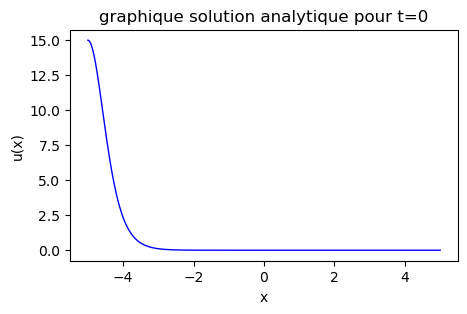

In [123]:
# ----------------------------------------
# Solution
# ----------------------------------------
# x : position 
# t : temps
def sol_an(x, t, eps, mu, c, x0):
    xi = x-c*t
    return 3*c/eps * sech(1/2 * math.sqrt(c/mu) * (xi-x0))**2

# ----------------------------------------
# Graphique pour la solution analytique
# ----------------------------------------
x = np.linspace(-5, 5, 1000)
u_t0 = sol_an(x, 0, 0.2, 0.1, 1, -5)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, u_t0, color='blue', linewidth=1)
ax.set_xlabel("x")
ax.set_ylabel("u(x)")
ax.set_title("graphique solution analytique pour t=0")
plt.show()

# Mise en place du schéma de Crank-Nikolson

In [124]:
# ----------------------------------------
# Schéma de Crank-Nikolson avec résolution du système 
# ----------------------------------------
def sol_ck (x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0) :
    #x_debut : point de depart du maillage en x
    #x_fin : point de fin du maillage en x
    #Tf : temps de fin du maillage
    #Nx : nombre de subdivision en X
    #Nt : nombre de subdivision en temps

    t = 0 #temps de début

    #Pas du maillage
    hx = (x_fin - x_debut)/(Nx-1)
    ht = Tf/Nt
    
    #Constantes 
    alpha = (mu * ht) / (hx**3)
    beta = (eps * ht) / hx

    x = np.linspace(x_debut, x_fin, Nx)
    #Creation des matrices / vect
    Un = np.zeros((Nt,Nx))
    #Creation des matrices / vect
    Un[0,:] = sol_an(x, 0, eps, mu, c, x0)
    matA = np.zeros ((Nx,Nx))
    MatB = np.zeros ((Nx,Nx))


    #Cond. de Dirichlet Un+1 = Un pour i = 0,1 & i = N-1,N
    matA[0,0] = matA[1,1] = 1 
    MatB[0,0] = MatB[1,1] = 1
    matA[Nx-2, Nx-2] = matA[Nx-1, Nx-1] = 1
    MatB[Nx-2, Nx-2] = MatB[Nx-1, Nx-1] = 1
     
    
    for i in range(1,Nt) : #a chaque temps
        gamma = (alpha / 2) - (beta / 4) * Un[i-1, :]

        for j in range(2, Nx - 2):
            matA[j, j-2] = -alpha / 4
            matA[j, j-1] = gamma[j]
            matA[j, j]   = 1
            matA[j, j+1] = -gamma[j]
            matA[j, j+2] = alpha / 4
            
            MatB[j, j-2] = alpha / 4
            MatB[j, j-1] = -gamma[j]
            MatB[j, j]   = 1
            MatB[j, j+1] = gamma[j]
            MatB[j, j+2] = -alpha / 4
            
        # b = B * Un
        b = np.dot(MatB, Un[i-1,:]) # Moins performant de passer MatB en sparse
        
        # Résolution A * Un+1 = b
        Un[i, :] = np.linalg.solve(matA, b)

    return Un , x

In [125]:
# ----------------------------------------
# Schéma de Crank-Nikolson avec résolution du système pour une matrice sparse
# ----------------------------------------
def sol_ck_sparse (x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0) :
    #x_debut : point de depart du maillage en x
    #x_fin : point de fin du maillage en x
    #Tf : temps de fin du maillage
    #Nx : nombre de subdivision en X
    #Nt : nombre de subdivision en temps

    t = 0 #temps de début

    #Pas du maillage
    hx = (x_fin - x_debut)/(Nx-1)
    ht = Tf/Nt
    
    #Constantes 
    alpha = (mu * ht) / (hx**3)
    beta = (eps * ht) / hx

    x = np.linspace(x_debut, x_fin, Nx)
    Un = np.zeros((Nt,Nx))
    #Creation des matrices / vect
    Un[0,:] = sol_an(x, 0, eps, mu, c, x0)

    diag_0 = np.ones(Nx) #diag princpale

    # Creation des diagonales des matrices, m2 = moins 2 (decalage -2), p2 = plus 2
    diag_m2A = np.zeros(Nx - 2)
    diag_p2A = np.zeros(Nx - 2)
    diag_m2B = np.zeros(Nx - 2)
    diag_p2B = np.zeros(Nx - 2)

    #Cond. de Dirichlet Un+1 = Un pour i = 0,1 & i = N-1,N
    diag_m2A[0:Nx-4] = -alpha / 4
    diag_p2A[2:Nx-2] = alpha / 4
    
    diag_m2B[0:Nx-4] = alpha / 4
    diag_p2B[2:Nx-2] = -alpha / 4



    for i in range(1,Nt) : # a chaque temps
        gamma = (alpha / 2) - (beta / 4) * Un[i-1,:]

        #diag decalage + - 1 a recalculer a chaque boucle
        diag_m1A = np.zeros(Nx - 1)
        diag_p1A = np.zeros(Nx - 1)
        diag_m1B = np.zeros(Nx - 1)
        diag_p1B = np.zeros(Nx - 1)


        diag_m1A[1:Nx-3] = gamma[2:Nx-2]
        diag_p1A[2:Nx-2] = -gamma[2:Nx-2]
        
        diag_m1B[1:Nx-3] = -gamma[2:Nx-2]
        diag_p1B[2:Nx-2] = gamma[2:Nx-2]

        # Stockage sparse de A        
        matA_sp = diags([diag_m2A, diag_m1A, diag_0, diag_p1A, diag_p2A], 
                        [-2, -1, 0, 1, 2], format='csr')
        
        MatB_sp = diags([diag_m2B, diag_m1B, diag_0, diag_p1B, diag_p2B], 
                        [-2, -1, 0, 1, 2], format='csr')
        
        # b = B * Un
        b = MatB_sp.dot(Un[i-1, :]) 

        # Résolution A * Un+1 = b
        Un[i, :] = spsolve(matA_sp, b)        

    return Un , x


# def sol_ck_sparse(x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0):
#     hx = (x_fin - x_debut) / (Nx - 1)
#     ht = Tf / Nt
    
#     alpha = (mu * ht) / (hx**3)
#     beta = (eps * ht) / hx

#     x = np.linspace(x_debut, x_fin, Nx)
#     Un = np.zeros((Nt, Nx))
    
#     # Transmission des paramètres à la solution analytique
#     Un[0, :] = sol_an(x, 0, x0, c, eps, mu) 
    
#     matA = np.zeros((Nx, Nx))
#     MatB = np.zeros((Nx, Nx))

#     matA[0,0] = matA[1,1] = 1 
#     MatB[0,0] = MatB[1,1] = 1
#     matA[Nx-2, Nx-2] = matA[Nx-1, Nx-1] = 1
#     MatB[Nx-2, Nx-2] = MatB[Nx-1, Nx-1] = 1
     
#     for i in range(1, Nt): 
#         gamma = (alpha / 2) - (beta / 4) * Un[i-1, :]

#         for j in range(2, Nx - 2):
#             matA[j, j-2] = -alpha / 4
#             matA[j, j-1] = gamma[j]
#             matA[j, j]   = 1
#             matA[j, j+1] = -gamma[j]
#             matA[j, j+2] = alpha / 4
            
#             MatB[j, j-2] = alpha / 4
#             MatB[j, j-1] = -gamma[j]
#             MatB[j, j]   = 1
#             MatB[j, j+1] = gamma[j]
#             MatB[j, j+2] = -alpha / 4

#         matA_sp = csr_matrix(matA)
#         b = np.dot(MatB, Un[i-1, :]) 
#         Un[i, :] = spsolve(matA_sp, b)

#     return Un, x

In [126]:
def UEX (x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0):
    #x_debut : point de depart du maillage en x
    #x_fin : point de fin du maillage en x
    #Tf : temps de fin du maillage
    #Nx : nombre de subdivision en X
    #Nt : nombre de subdivision en temps

    t = 0 #temps de début

    x = np.linspace(x_debut, x_fin, Nx)
    Un = np.zeros((Nt,Nx))

    for i in range(Nt) :
        Un[i,:] = sol_an(x, i * Tf / Nt, eps, mu, c, x0)

    return Un, x
    

In [127]:
# ----------------------------------------
# Schéma de Crank-Nicolson Prédicteur-Correcteur avec matrices sparse
# ----------------------------------------
def sol_ck_sparse_PC(x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0):
    #x_debut : point de depart du maillage en x
    #x_fin : point de fin du maillage en x
    #Tf : temps de fin du maillage
    #Nx : nombre de subdivision en X
    #Nt : nombre de subdivision en temps

    t = 0 #temps de début

    # Pas du maillage
    hx = (x_fin - x_debut) / (Nx - 1)
    ht = Tf / Nt
    
    # Constantes 
    alpha = (mu * ht) / (hx**3)
    beta = (eps * ht) / hx

    x = np.linspace(x_debut, x_fin, Nx)
    Un = np.zeros((Nt, Nx))
    
    # Creation des matrices / vect
    Un[0, :] = sol_an(x, 0, eps, mu, c, x0)

    diag_0 = np.ones(Nx) # diag princpale

    # Creation des diagonales des matrices, m2 = moins 2 (decalage -2), p2 = plus 2
    diag_m2A = np.zeros(Nx - 2)
    diag_p2A = np.zeros(Nx - 2)
    diag_m2B = np.zeros(Nx - 2)
    diag_p2B = np.zeros(Nx - 2)

    # Cond. de Dirichlet Un+1 = Un pour i = 0,1 & i = N-1,N
    diag_m2A[0:Nx-4] = -alpha / 4
    diag_p2A[2:Nx-2] = alpha / 4
    
    diag_m2B[0:Nx-4] = alpha / 4
    diag_p2B[2:Nx-2] = -alpha / 4

    for i in range(1, Nt): # a chaque temps
        
        # prediction; on gele le terme non lineaire a l'instant present
        gamma_pred = (alpha / 2) - (beta / 4) * Un[i-1, :]

        #diag decalage + - 1 a recalculer a chaque boucle
        diag_m1A = np.zeros(Nx - 1)
        diag_p1A = np.zeros(Nx - 1)
        diag_m1B = np.zeros(Nx - 1)
        diag_p1B = np.zeros(Nx - 1)

        diag_m1A[1:Nx-3] = gamma_pred[2:Nx-2]
        diag_p1A[2:Nx-2] = -gamma_pred[2:Nx-2]
        
        diag_m1B[1:Nx-3] = -gamma_pred[2:Nx-2]
        diag_p1B[2:Nx-2] = gamma_pred[2:Nx-2]

        # Stockage sparse de A
        matA_sp = diags([diag_m2A, diag_m1A, diag_0, diag_p1A, diag_p2A],   
                        [-2, -1, 0, 1, 2], format='csr')
        MatB_sp = diags([diag_m2B, diag_m1B, diag_0, diag_p1B, diag_p2B], 
                        [-2, -1, 0, 1, 2], format='csr')
        
        # b = B * Un
        b = MatB_sp.dot(Un[i-1, :]) 
        
        # Résolution A * Un+1 = b
        U_pred = spsolve(matA_sp, b)        

        # correction
        # On centre le terme non linéaire
        gamma_corr = (alpha / 2) - (beta / 4) * ((Un[i-1, :] + U_pred) / 2)

        # maj des diag
        diag_m1A[1:Nx-3] = gamma_corr[2:Nx-2]
        diag_p1A[2:Nx-2] = -gamma_corr[2:Nx-2]
        
        diag_m1B[1:Nx-3] = -gamma_corr[2:Nx-2]
        diag_p1B[2:Nx-2] = gamma_corr[2:Nx-2]

        matA_sp = diags([diag_m2A, diag_m1A, diag_0, diag_p1A, diag_p2A], 
                        [-2, -1, 0, 1, 2], format='csr')
        MatB_sp = diags([diag_m2B, diag_m1B, diag_0, diag_p1B, diag_p2B], 
                        [-2, -1, 0, 1, 2], format='csr')
        
        b = MatB_sp.dot(Un[i-1, :]) 

        Un[i, :] = spsolve(matA_sp, b)        

    return Un, x

# Calcul des solutions & mesure des temps de Calcul

In [128]:
c = 1.0       # Vitesse du soliton
eps = 0.2
mu = 0.1
x0 = -5.0     # Point de départ de la vague

x_debut = -15.0
x_fin = 15.0
Tf = 10.0   

Nx = 1000     
Nt = 700     

In [129]:
# Matrice pleine
# start_sol_ck = time.perf_counter()
# U_numerique_final, x_num = sol_ck(x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0)
# end_sol_ck = time.perf_counter()

In [130]:
# Matrice sparse
start_sol_ck_sp = time.perf_counter()
U_num_sp, x_num_sp = sol_ck_sparse(x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0)
end_sol_ck_sp = time.perf_counter()

In [131]:
# Crank nikolson PC
start_sol_sp_pc = time.perf_counter()
U_num_sp_pc, x_num_sp_pc = sol_ck_sparse_PC(x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0)
end_sol_sp_pc = time.perf_counter()

In [132]:
# Calcul de la théorie exacte au temps final pour comparaison
start_sol_an = time.perf_counter()
U_ex, x_ex = UEX(x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0)
end_sol_an = time.perf_counter()
U_analytique = sol_an(x_num_sp, Tf, eps, mu, c, x0)

In [133]:
# Temps de calculs
# print(f"Temps d'exécution solution numérique Matrice pleine : {end_sol_ck - start_sol_ck} secondes")
print(f"Temps CN Sparse classique : {end_sol_ck_sp - start_sol_ck_sp:.4f} s")
print(f"Temps CN Prédicteur-Correcteur : {end_sol_sp_pc - start_sol_sp_pc:.4f} s")
print(f"Temps Solution Analytique : {end_sol_an - start_sol_an:.4f} s")

Temps CN Sparse classique : 0.6536 s
Temps CN Prédicteur-Correcteur : 1.2607 s
Temps Solution Analytique : 0.0158 s


# Comparaison des résultats numérique et de la solution analytique (Q2)

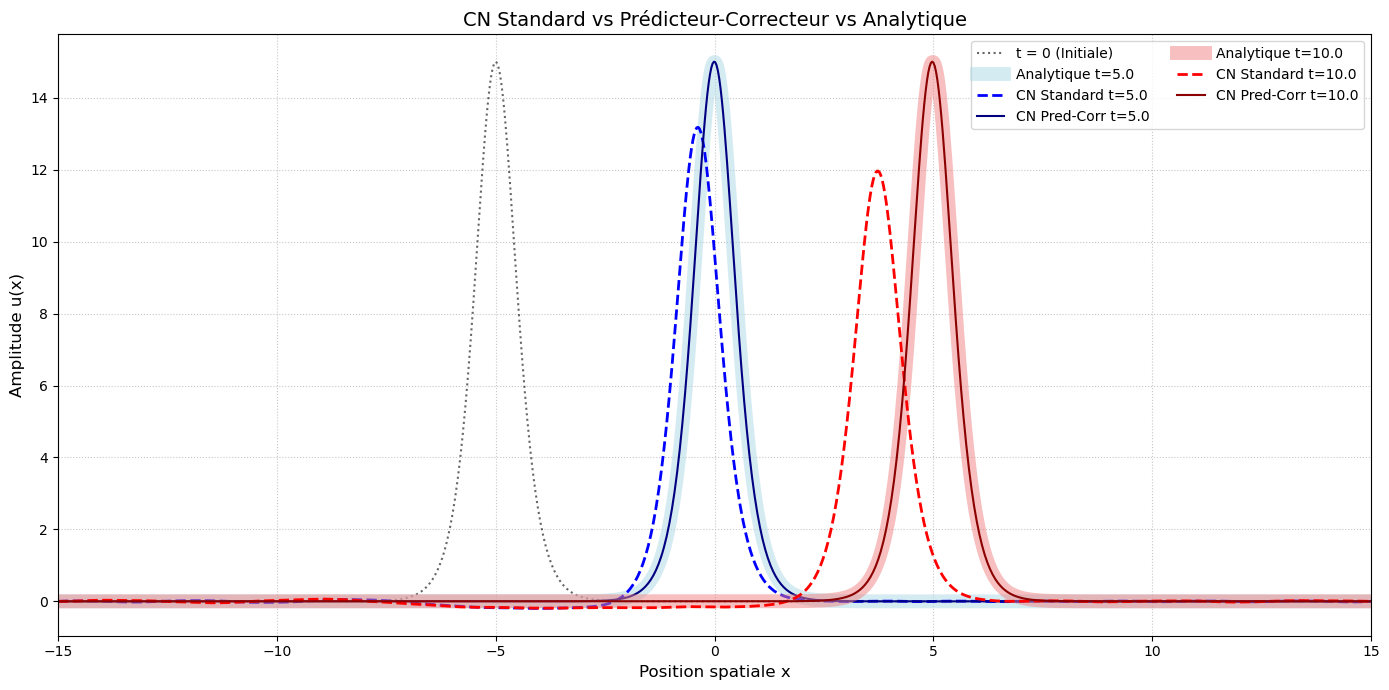

In [134]:
idx_mid = Nt // 2  
idx_fin = Nt - 1   
t_mid = Tf / 2     

plt.figure(figsize=(14, 7))

# etat initial
plt.plot(x_num_sp, U_ex[0, :], ls=':', color='black', alpha=0.6, label='t = 0 (Initiale)')

# etat milieu
plt.plot(x_num_sp, U_ex[idx_mid, :], ls='-', color='lightblue', lw=10, alpha=0.5, label=f'Analytique t={t_mid}')
plt.plot(x_num_sp, U_num_sp[idx_mid, :], ls='--', color='blue', lw=2, label=f'CN Standard t={t_mid}')
plt.plot(x_num_sp_pc, U_num_sp_pc[idx_mid, :], ls='-', color='navy', lw=1.5, label=f'CN Pred-Corr t={t_mid}')

# etat final
plt.plot(x_num_sp, U_ex[idx_fin, :], ls='-', color='lightcoral', lw=10, alpha=0.5, label=f'Analytique t={Tf}')
plt.plot(x_num_sp, U_num_sp[idx_fin, :], ls='--', color='red', lw=2, label=f'CN Standard t={Tf}')
plt.plot(x_num_sp_pc, U_num_sp_pc[idx_fin, :], ls='-', color='darkred', lw=1.5, label=f'CN Pred-Corr t={Tf}')

plt.xlabel("Position spatiale x", fontsize=12)
plt.ylabel("Amplitude u(x)", fontsize=12)
plt.title("CN Standard vs Prédicteur-Correcteur vs Analytique", fontsize=14)

plt.legend(loc='upper right', ncol=2, fontsize=10, frameon=True)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.xlim(x_debut, x_fin)
plt.tight_layout()

plt.show()

# Schema explicite

In [135]:
def solve_kdv_expl(x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0):
    x = np.linspace(x_debut, x_fin, Nx)
    hx = (x_fin - x_debut) / (Nx - 1)
    ht = Tf / Nt
    
    U = np.zeros((Nt, Nx))
    U[0, :] = sol_an(x, 0, eps, mu, c, x0)
    
    u_x = np.zeros(Nx)
    u_xxx = np.zeros(Nx)
    
    #euler explicite
    u = U[0, :]
    u_x[1:-1] = (u[2:] - u[:-2]) / (2 * hx)
    u_xxx[2:-2] = (u[4:] - 2*u[3:-1] + 2*u[1:-3] - u[:-4]) / (2 * hx**3)
    
    U[1, :] = u - ht * (eps * u * u_x + mu * u_xxx)
    
    for n in range(1, Nt - 1):
        u = U[n, :]
        
        u_x.fill(0)
        u_xxx.fill(0)
        
        u_x[1:-1] = (u[2:] - u[:-2]) / (2 * hx)
        u_xxx[2:-2] = (u[4:] - 2*u[3:-1] + 2*u[1:-3] - u[:-4]) / (2 * hx**3)
        
        U[n+1, 2:-2] = U[n-1, 2:-2] - 2 * ht * (eps * u[2:-2] * u_x[2:-2] + mu * u_xxx[2:-2])
        
        
    return U, x

In [136]:
eps, mu, c, x0 = 0.2, 0.1, 1.0, -5.0
x_deb, x_fin, Tf = -15, 15, 5.0 
Nx = 400
Nt = 50000 

start_time = time.perf_counter()
U_explicite, x_axis = solve_kdv_expl(x_deb, x_fin, Tf, Nx, Nt, eps, mu, c, x0)
end_time = time.perf_counter()

print(f"Temps de résolution (Explicite Leapfrog) : {end_time - start_time:.4f} secondes")

Temps de résolution (Explicite Leapfrog) : 1.1218 secondes


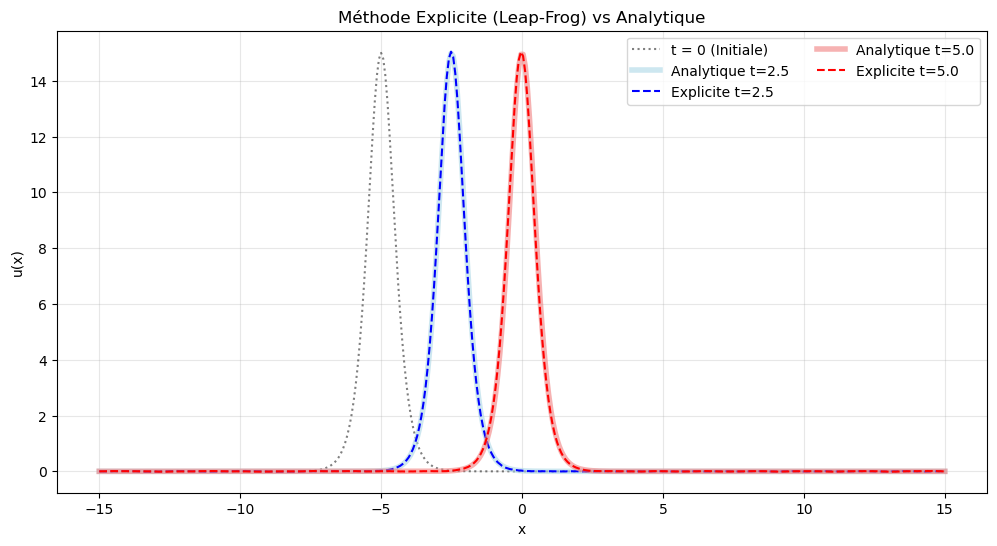

In [137]:
# Graphique
idx_mid = Nt // 2
idx_fin = Nt - 1
t_mid = Tf / 2

plt.figure(figsize=(12, 6))
plt.plot(x_axis, U_explicite[0, :], ':', color='black', alpha=0.5, label='t = 0 (Initiale)')

#temps intermediaire
U_ana_mid = sol_an(x_axis, t_mid, eps, mu, c, x0)
plt.plot(x_axis, U_ana_mid, '-', color='lightblue', lw=4, alpha=0.6, label=f'Analytique t={t_mid}')
plt.plot(x_axis, U_explicite[idx_mid, :], '--', color='blue', label=f'Explicite t={t_mid}')

#temps final
U_ana_fin = sol_an(x_axis, Tf, eps, mu, c, x0)
plt.plot(x_axis, U_ana_fin, '-', color='lightcoral', lw=4, alpha=0.6, label=f'Analytique t={Tf}')
plt.plot(x_axis, U_explicite[idx_fin, :], '--', color='red', label=f'Explicite t={Tf}')

plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Méthode Explicite (Leap-Frog) vs Analytique")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

# Animation

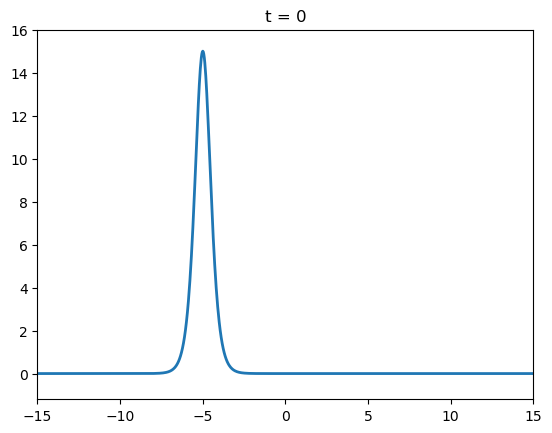

In [113]:

# Figure
fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2)

# Limites
ax.set_xlim(-15, 15)
ax.set_ylim(U_num_sp.min()-1, U_num_sp.max()+1)

# Fonction d'animation
def update(i):
    line.set_data(x_num_sp, U_num_sp[i, :])
    ax.set_title(f"t = {i}")
    return line

# Animation
ani = FuncAnimation(fig, update, frames=U_num_sp.shape[0],interval=30)

HTML(ani.to_html5_video())

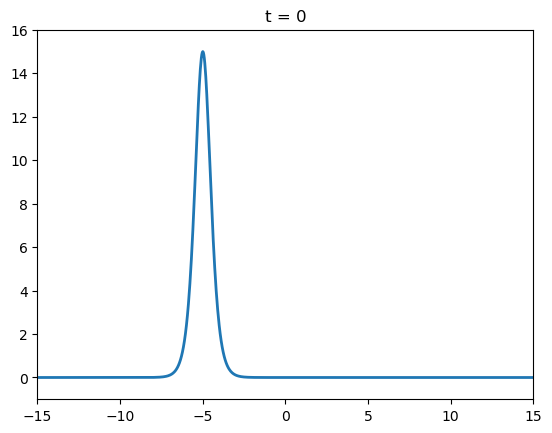

In [115]:
# Figure
fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2)

# Limites
ax.set_xlim(-15, 15)
ax.set_ylim(U_num_sp_pc.min()-1, U_num_sp_pc.max()+1)

# Fonction d'animation
def update(i):
    line.set_data(x_num_sp, U_num_sp_pc[i, :])
    ax.set_title(f"t = {i}")
    return line

# Animation
ani = FuncAnimation(fig, update, frames=U_num_sp_pc.shape[0],interval=30)

HTML(ani.to_html5_video())

KeyboardInterrupt: 

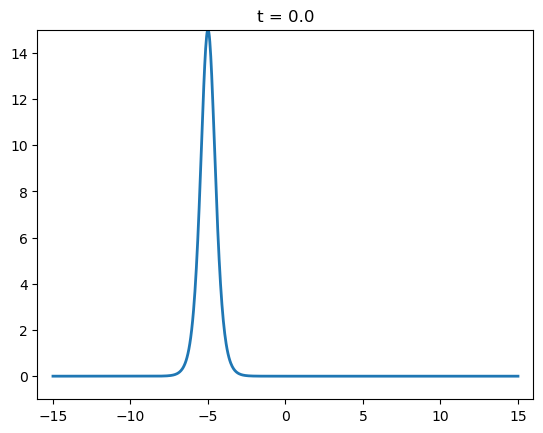

In [116]:
# Figure
fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2)

ax.set_xlim(x_num_sp.min()-1, x_num_sp.max()+1)
ax.set_ylim(-1, 15)

t = np.linspace(0, Tf, Nt)

def update2(i):
    y = sol_an(x_num_sp, t[i], eps, mu, c, x0)
    line.set_data(x_num_sp, y)
    ax.set_title(f"t = {t[i]}")
    return line,

ani = FuncAnimation(fig, update2, frames=len(t), interval=30)

HTML(ani.to_html5_video())

# Lien Amplitude - Vitesse (Q3)

In [117]:
# Vitesse du soliton
c1 = 0.5
c2 = 1.0
c3 = 2.0
c4 = 3.0

eps = 0.2
mu = 0.1
x0 = -5.0     # Point de départ de la vague

x_debut = -15.0
x_fin = 15.0
Tf = 10.0   

Nx = 700     
Nt = 1000    

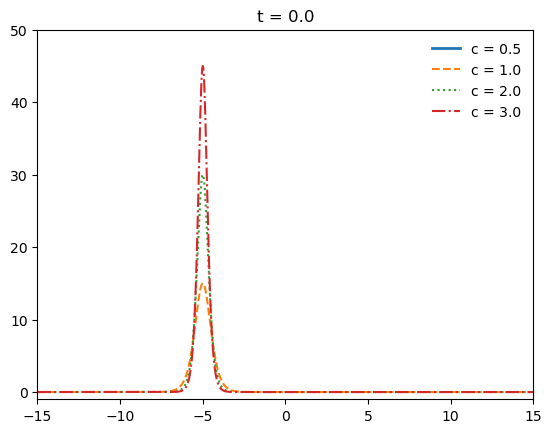

In [118]:
# Figure
fig, ax = plt.subplots()
line1, = ax.plot([], [], lw=2, label=f"c = {c1}")
line2, = ax.plot([], [], '--', label=f"c = {c2}")
line3, = ax.plot([], [], ':', label=f"c = {c3}")
line4, = ax.plot([], [], '-.', label=f"c = {c4}")

ax.set_xlim(-15, 15)
ax.set_ylim(-1, 50)
ax.legend(loc="upper right", frameon=False)

t = np.linspace(0, Tf, Nt)

def update3(i):
    
    y1 = sol_an(x_num_sp, t[i], eps, mu, c1, x0)
    y2 = sol_an(x_num_sp, t[i], eps, mu, c2, x0)
    y3 = sol_an(x_num_sp, t[i], eps, mu, c3, x0)
    y4 = sol_an(x_num_sp, t[i], eps, mu, c4, x0)
    
    line.set_data(x_num_sp, y1)
    line2.set_data(x_num_sp, y2)
    line3.set_data(x_num_sp, y3)
    line4.set_data(x_num_sp, y4)
    
    ax.set_title(f"t = {t[i]}")
    return line1, line2, line3, line4

ani = FuncAnimation(fig, update3, frames=len(t), interval=30)

HTML(ani.to_html5_video())

# Lorsqu'un soliton en dépasse un autre

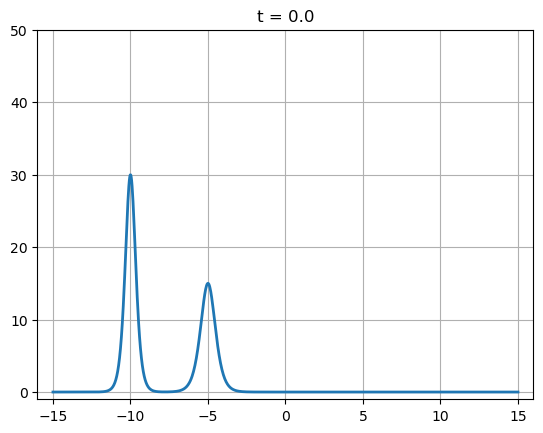

In [119]:
# Figure
fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2)

ax.set_xlim(x_num_sp.min()-1, x_num_sp.max()+1)
ax.set_ylim(-1, 50)
ax.grid()

t = np.linspace(0, Tf, Nt)

def update4(i):
    y = sol_an(x_num_sp, t[i], eps, mu, c3, -10.0) + sol_an(x_num_sp, t[i], eps, mu, c2, -5.0)
    line.set_data(x_num_sp, y)
    ax.set_title(f"t = {t[i]}")
    return line,

ani = FuncAnimation(fig, update4, frames=len(t), interval=30)

HTML(ani.to_html5_video())